# 03 · Analysis & figures
Turns the result CSVs into the tables and figures for the paper:
1. Calibration table (RQ1)
2. Coverage & efficiency by model (RQ2)
3. **Coverage gap: marginal vs Mondrian** (RQ3 — the headline figure)
4. Reliability diagram for a representative case
5. Across-dataset ranking with significance (Tier B)

In [ ]:
import os, sys, pathlib, certifi
# --- Secrets: load HF_TOKEN / TABPFN_TOKEN from a local, gitignored .env if present
#     (see .env.example). Never hardcode tokens. Accept the TabPFN license once at
#     https://ux.priorlabs.ai, then put your tokens in .env.
for _p in (pathlib.Path(".env"), pathlib.Path("..") / ".env"):
    if _p.exists():
        for _line in _p.read_text().splitlines():
            _line = _line.strip()
            if _line and not _line.startswith("#") and "=" in _line:
                _k, _v = _line.split("=", 1)
                os.environ.setdefault(_k.strip(), _v.strip().strip('"').strip("'"))
        break
os.environ.setdefault("SSL_CERT_FILE", certifi.where())
os.environ.setdefault("REQUESTS_CA_BUNDLE", certifi.where())
from tabpfn import TabPFNClassifier
sys.path.append(os.path.abspath('..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
os.makedirs('../figures', exist_ok=True)
calib = pd.read_csv('../results/calibration.csv')
conf  = pd.read_csv('../results/conformal_fairness.csv')
print(calib.shape, conf.shape)

### 1 · Calibration table (RQ1) — mean ± std over seeds

In [2]:
g = (calib.groupby('model')[['accuracy','ece_adaptive','brier','nll']]
          .agg(['mean','std']).round(4))
g

accuracy         ece_adaptive           brier             nll  \
                mean     std         mean     std    mean     std    mean   
model                                                                       
lightgbm      0.7692  0.0492       0.0518  0.0115  0.3174  0.0574  0.4852   
mlp           0.7590  0.0464       0.0254  0.0074  0.3241  0.0558  0.4860   
tabpfn        0.7823  0.0462       0.0258  0.0063  0.2978  0.0557  0.4521   
tabpfn_temp   0.7823  0.0462       0.0245  0.0056  0.2974  0.0555  0.4509   
xgboost       0.7630  0.0515       0.0749  0.0185  0.3333  0.0637  0.5163   

                     
                std  
model                
lightgbm     0.0742  
mlp          0.0742  
tabpfn       0.0746  
tabpfn_temp  0.0744  
xgboost      0.0843

### 2 · Conformal validity & efficiency (RQ2)
Marginal coverage should sit near the target; smaller set size = better.

In [3]:
m = conf[(conf.method=='marginal') & (conf.axis=='predclass')]
tab = (m.groupby(['model','target_coverage'])
        [['marginal_coverage','mean_set_size']].mean().round(3))
tab

marginal_coverage  mean_set_size
model       target_coverage                                  
lightgbm    0.80                         0.901          1.534
            0.90                         0.950          1.664
            0.95                         0.976          1.759
mlp         0.80                         0.901          1.547
            0.90                         0.951          1.681
            0.95                         0.975          1.771
tabpfn      0.80                         0.905          1.524
            0.90                         0.950          1.648
            0.95                         0.975          1.740
tabpfn_temp 0.80                         0.905          1.524
            0.90                         0.950          1.648
            0.95                         0.975          1.740
xgboost     0.80                         0.900          1.541
            0.90                         0.950          1.670
            0.95                         0.976          1.767

### 3 · Coverage gap — marginal vs Mondrian (RQ3, headline)
Lower gap = fairer. Mondrian should reduce the gap; note any set-size cost.

method,marginal,mondrian
model,,
lightgbm,0.006,0.007
mlp,0.007,0.005
tabpfn,0.005,0.005
tabpfn_temp,0.005,0.005
xgboost,0.006,0.009


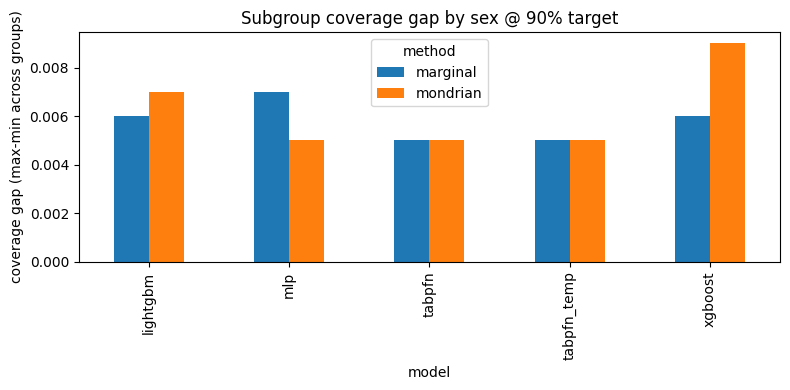

In [4]:
AXIS = 'sex'   # try 'race', 'age', 'predclass'
sub = conf[(conf.axis==AXIS) & (conf.target_coverage==0.90)]
piv = (sub.groupby(['model','method'])['coverage_gap']
          .mean().unstack().round(3))
display(piv)

ax = piv.plot(kind='bar', figsize=(8,4))
ax.set_ylabel('coverage gap (max-min across groups)')
ax.set_title(f'Subgroup coverage gap by {AXIS} @ 90% target')
plt.tight_layout(); plt.savefig(f'../figures/coverage_gap_{AXIS}.png', dpi=150); plt.show()

In [5]:
# companion: efficiency cost of Mondrian (set-size disparity)
piv2 = (sub.groupby(['model','method'])['mean_set_size']
           .mean().unstack().round(3))
piv2

method,marginal,mondrian
model,,
lightgbm,1.664,1.665
mlp,1.681,1.681
tabpfn,1.648,1.649
tabpfn_temp,1.648,1.649
xgboost,1.670,1.672


### 4 · Reliability diagram for a representative case
Recomputed live (cheap) so we can show the curve, not just a number.

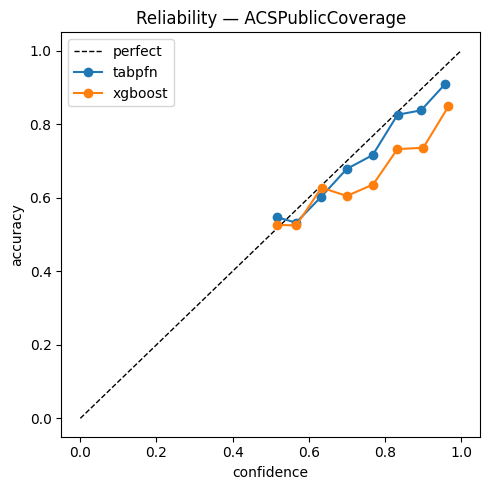

In [6]:
from src.data_loaders import load_folktables
from src.models import build_model
from src.pipeline import three_way_split
from src.calibration import reliability_curve

d = load_folktables(task='ACSPublicCoverage', state='CA', seed=0)
(Xtr,ytr,_),(Xcal,ycal,_),(Xte,yte,ste) = three_way_split(d['X'],d['y'],d['sensitive'],0)
plt.figure(figsize=(5,5)); plt.plot([0,1],[0,1],'k--',lw=1,label='perfect')
for name in ['tabpfn','xgboost']:
    mdl = build_model(name,0); mdl.fit(Xtr,ytr)
    x,y_,_ = reliability_curve(mdl.predict_proba(Xte), yte)
    plt.plot(x,y_,'o-',label=name)
plt.xlabel('confidence'); plt.ylabel('accuracy'); plt.legend()
plt.title('Reliability — ACSPublicCoverage'); plt.tight_layout()
plt.savefig('../figures/reliability_example.png', dpi=150); plt.show()

### 5 · Across-dataset ranking with significance (Tier B)
Friedman + Nemenyi over Tier-B datasets, ranking models by |coverage − target|.

In [7]:
from src.stats_utils import friedman_nemenyi
tierB = conf[conf.dataset.str.startswith('openml-') &
             (conf.method=='marginal') & (conf.axis=='predclass') &
             (conf.target_coverage==0.90)].copy()
if len(tierB):
    tierB['cov_err'] = (tierB['marginal_coverage'] - 0.90).abs()
    mat = tierB.groupby(['dataset','model'])['cov_err'].mean().unstack()
    models = list(mat.columns)
    p, ranks, nem = friedman_nemenyi(mat.values, models)
    print('Friedman p =', round(p,4))
    print('avg ranks  :', {k: round(v,2) for k,v in ranks.items()})
else:
    print('No Tier-B rows yet — run the full (QUICK=False) experiment first.')

No Tier-B rows yet — run the full (QUICK=False) experiment first.


**Reading the results:** the story is whichever of these holds — TabPFN is better/worse calibrated than GBDTs (RQ1); its conformal sets are smaller at equal coverage (RQ2); its marginal coverage hides subgroup gaps that Mondrian repairs (RQ3). Report direction honestly; all are publishable.